In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from datetime import datetime
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from tensorflow.keras import layers, initializers
from tqdm.notebook import tqdm


print(f'GPUs Available: {len(tf.config.list_physical_devices("GPU"))}')
print(f'Device name: {tf.test.gpu_device_name()}')

GPUs Available: 1
Device name: /device:GPU:0


In [2]:
# Normalised input features
INPUT_SIGNAL_TYPES = [
    "XMV(1)", "XMV(2)", "XMV(3)", "XMV(4)", "XMV(5)", "XMV(6)", "XMV(7)", "XMV(8)", "XMV(9)", "XMV(10)", "XMV(11)"
]

# Output classes
LABELS = ["NORMAL ", "FAULT 1", "FAULT 2", "FAULT 3", "FAULT 4", "FAULT 5", "FAULT 7"]

# Input folders paths
DATASET_PATH = "tep/input/tep_dataset/"

TRAIN = "train/"
TEST = "test/"

X_train_signals_paths = [DATASET_PATH + TRAIN + signal + ".txt" for signal in INPUT_SIGNAL_TYPES]
X_test_signals_paths = [DATASET_PATH + TEST + signal + ".txt" for signal in INPUT_SIGNAL_TYPES]

y_train_path = DATASET_PATH + TRAIN + "idv.txt"
y_test_path = DATASET_PATH + TEST + "idv.txt"


# Helper functions
def load_X(X_signals_paths):
    # Function returns the input features tensor.
    X_signals = []
    for signal_type_path in X_signals_paths:
        with open(signal_type_path, 'r') as file:
            # Read dataset from disk, dealing with text files' syntax
            X_signals.append([np.array(serie, dtype=np.float32) for serie in [row.split(' ') for row in file]])
    return np.transpose(np.array(X_signals), (1, 2, 0))


def load_y(y_path):
    # Function returns the fault labels vector.
    with open(y_path, 'r') as file:
        # Read dataset from disk, dealing with text file's syntax
        y_ = np.array([elem for elem in [row.split(' ') for row in file]], dtype=np.int32)
    return y_


def model_size(model):
    return np.sum([np.prod(np.array(var.numpy().shape)) for var in model.trainable_variables])


class StackedLSTM(tf.keras.Model):

    def __init__(self):
        super(StackedLSTM, self).__init__()

        self.dense1 = layers.Dense(32,
                                   activation='relu',
                                   kernel_initializer=initializers.RandomNormal(stddev=1.),
                                   bias_initializer=initializers.RandomNormal(stddev=1.))

        self.dense2 = layers.Dense(8,
                                   kernel_initializer=initializers.RandomNormal(mean=1., stddev=1.),
                                   bias_initializer=initializers.RandomNormal(stddev=1.))

        self.lstm1 = layers.LSTM(32, return_sequences=True)
        self.lstm2 = layers.LSTM(32)

    def build(self, input_shape):
        self.dense1.build(input_shape)
        self.lstm1.build(self.dense1.compute_output_shape(input_shape))
        self.lstm2.build(self.lstm1.compute_output_shape(self.dense1.compute_output_shape(input_shape)))
        self.dense2.build(self.lstm2.compute_output_shape(self.lstm1.compute_output_shape(self.dense1.compute_output_shape(input_shape))))

        super(StackedLSTM, self).build(input_shape)  # Don't forget to call the build method of the parent class

    def call(self, x):
        x = self.dense1(x)
        x = self.lstm1(x)
        x = self.lstm2(x)
        x = self.dense2(x)
        return x

In [3]:
# Input features tensors
X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

# Fault labels
y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("Some useful info to get an insight on dataset's shape and normalisation:")
print("(X shape, y shape, every X's mean, every X's standard deviation)")
print(X_test.shape, y_test.shape, np.mean(X_test), np.std(X_test))
print("The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.")
print("")
unique_elements, counts_elements = np.unique(y_train, return_counts=True)
print('Faults distribution in the training set:')
print(np.asarray((unique_elements, counts_elements)))
unique_elements, counts_elements = np.unique(y_test, return_counts=True)
print('\nFaults distribution in the test set:')
print(np.asarray((unique_elements, counts_elements)))

# Input tensor data
training_data_count = len(X_train)  # 5733 training sequences (with 50% overlap between each sequence)
test_data_count = len(X_test)       # 2458 testing sequences
n_steps = len(X_train[0])           # 128 timesteps per sequence
n_input = len(X_train[0][0])        # 11 input features per timestep

Some useful info to get an insight on dataset's shape and normalisation:
(X shape, y shape, every X's mean, every X's standard deviation)
(2458, 128, 11) (2458, 1) -0.0012041103 0.99738777
The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.

Faults distribution in the training set:
[[   0    1    2    3    4    5    7]
 [4709  172  168  162  117  184  221]]

Faults distribution in the test set:
[[   0    1    2    3    4    5    7]
 [2030   65   63   75   54   68  103]]


In [4]:
# Parameters
epochs = 300
batch_size = 1500
learning_rate = 0.0025
reg_lambda = 0.0015

model = StackedLSTM()
model.build(input_shape=(None, 128, 11))
model.save_weights('.\\models\\initial_weights.weights.h5')

regularizer = tf.keras.regularizers.L2(l2=reg_lambda)
loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')

In [5]:
X = np.vstack((X_train, X_test))
y = np.vstack((y_train, y_test))

print(f'Train data:\t{X_train.shape}, {y_train.shape}')
print(f'Test data:\t{X_test.shape}, {y_test.shape}')
print(f'Data:\t\t{X.shape}, {y.shape}')

Train data:	(5733, 128, 11), (5733, 1)
Test data:	(2458, 128, 11), (2458, 1)
Data:		(8191, 128, 11), (8191, 1)


In [6]:
@tf.function
def train_step(x_batch, y_batch, model):
    with tf.GradientTape() as tape:
        y_batch_pred = model(x_batch)
        loss = loss_func(y_batch, y_batch_pred)
        loss += tf.math.reduce_sum([regularizer(var) for var in model.trainable_variables])
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_loss(loss)
    train_accuracy(y_batch, y_batch_pred)


@tf.function
def test_step(x_batch, y_batch, model):
    y_batch_pred = model(x_batch)
    loss = loss_func(y_batch, y_batch_pred)
    loss += tf.math.reduce_sum([regularizer(var) for var in model.trainable_variables])

    test_loss(loss)
    test_accuracy(y_batch, y_batch_pred)


def model_training(train_ds, test_ds):
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    start = datetime.now()

    for epoch in range(epochs):
        train_loss.reset_state()
        train_accuracy.reset_state()
        test_loss.reset_state()
        test_accuracy.reset_state()

        for x_batch, y_batch in tqdm(train_ds, desc=f'Epoch {epoch + 1} [Train]'):
            train_step(x_batch, y_batch, model)

        for x_batch, y_batch in tqdm(test_ds, desc=f'Epoch {epoch + 1} [Test]'):
            test_step(x_batch, y_batch, model)

        train_losses.append(train_loss.result().numpy())
        test_losses.append(test_loss.result().numpy())
        train_accuracies.append(train_accuracy.result().numpy())
        test_accuracies.append(test_accuracy.result().numpy())

        print(f'Epoch {epoch + 1}, ', end='')
        print(f'Loss: {train_loss.result().numpy():.4f}, ', end='')
        print(f'Accuracy: {(train_accuracy.result().numpy() * 100):.4f} %, ', end='')
        print(f'Test Loss: {test_loss.result().numpy():.4f}, ', end='')
        print(f'Test Accuracy: {(test_accuracy.result().numpy() * 100):.4f} %')

    print(f'\nExec Time: {datetime.now() - start}')
    return train_accuracies, test_accuracies, train_losses, test_losses

In [7]:
kf = KFold(n_splits=5)

folds_res = []
for index, (train_index, test_index) in enumerate(kf.split(X)):
    fold = index + 1
    model.load_weights('.\\models\\initial_weights.weights.h5')

    train_ds = tf.data.Dataset.from_tensor_slices((X[train_index], y[train_index])).batch(batch_size)
    test_ds = tf.data.Dataset.from_tensor_slices((X[test_index], y[test_index])).batch(batch_size)

    print(f'>> Fold {fold} training >>>>')
    train_accuracies, test_accuracies, train_losses, test_losses = model_training(train_ds, test_ds)
    print(f'[fold {fold}] Accuracy: {test_accuracies[-1] * 100:.4f} %\n')

    model.save_weights(f'.\\models\\{fold}-fold-model.weights.h5')
    folds_res.append({
        'fold': fold,
        'train_acc': train_accuracies,
        'test_acc': test_accuracies,
        'train_losses': train_losses,
        'test_losses': test_losses
    })

accuracies = np.array([res['test_acc'][-1] for res in folds_res])
print(f'Accuracy: {accuracies.mean():.4f} +/- {accuracies.std():.4f}')

>> Fold 1 training >>>>


Epoch 1 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 [Test]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1, Loss: 2.4103, Accuracy: 80.3724 %, Test Loss: 2.2135, Test Accuracy: 81.9402 %


Epoch 2 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 299 [Test]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 299, Loss: 0.2051, Accuracy: 97.5584 %, Test Loss: 0.3390, Test Accuracy: 96.7033 %


Epoch 300 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 300 [Test]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 300, Loss: 0.2211, Accuracy: 97.2837 %, Test Loss: 0.2773, Test Accuracy: 96.6422 %

Exec Time: 0:01:41.032028
[fold 5] Accuracy: 96.6422 %

Accuracy: 0.9712 +/- 0.0040


In [16]:
print(f'model parameters: {model_size(model)}\n')

for name, shape in [(var.path, var.shape) for var in model.trainable_variables]:
    print(f'{name}, {shape}')

model parameters: 17288

stacked_lstm/dense/kernel, (11, 32)
stacked_lstm/dense/bias, (32,)
stacked_lstm/dense_1/kernel, (32, 8)
stacked_lstm/dense_1/bias, (8,)
stacked_lstm/lstm/lstm_cell/kernel, (32, 128)
stacked_lstm/lstm/lstm_cell/recurrent_kernel, (32, 128)
stacked_lstm/lstm/lstm_cell/bias, (128,)
stacked_lstm/lstm_1/lstm_cell/kernel, (32, 128)
stacked_lstm/lstm_1/lstm_cell/recurrent_kernel, (32, 128)
stacked_lstm/lstm_1/lstm_cell/bias, (128,)


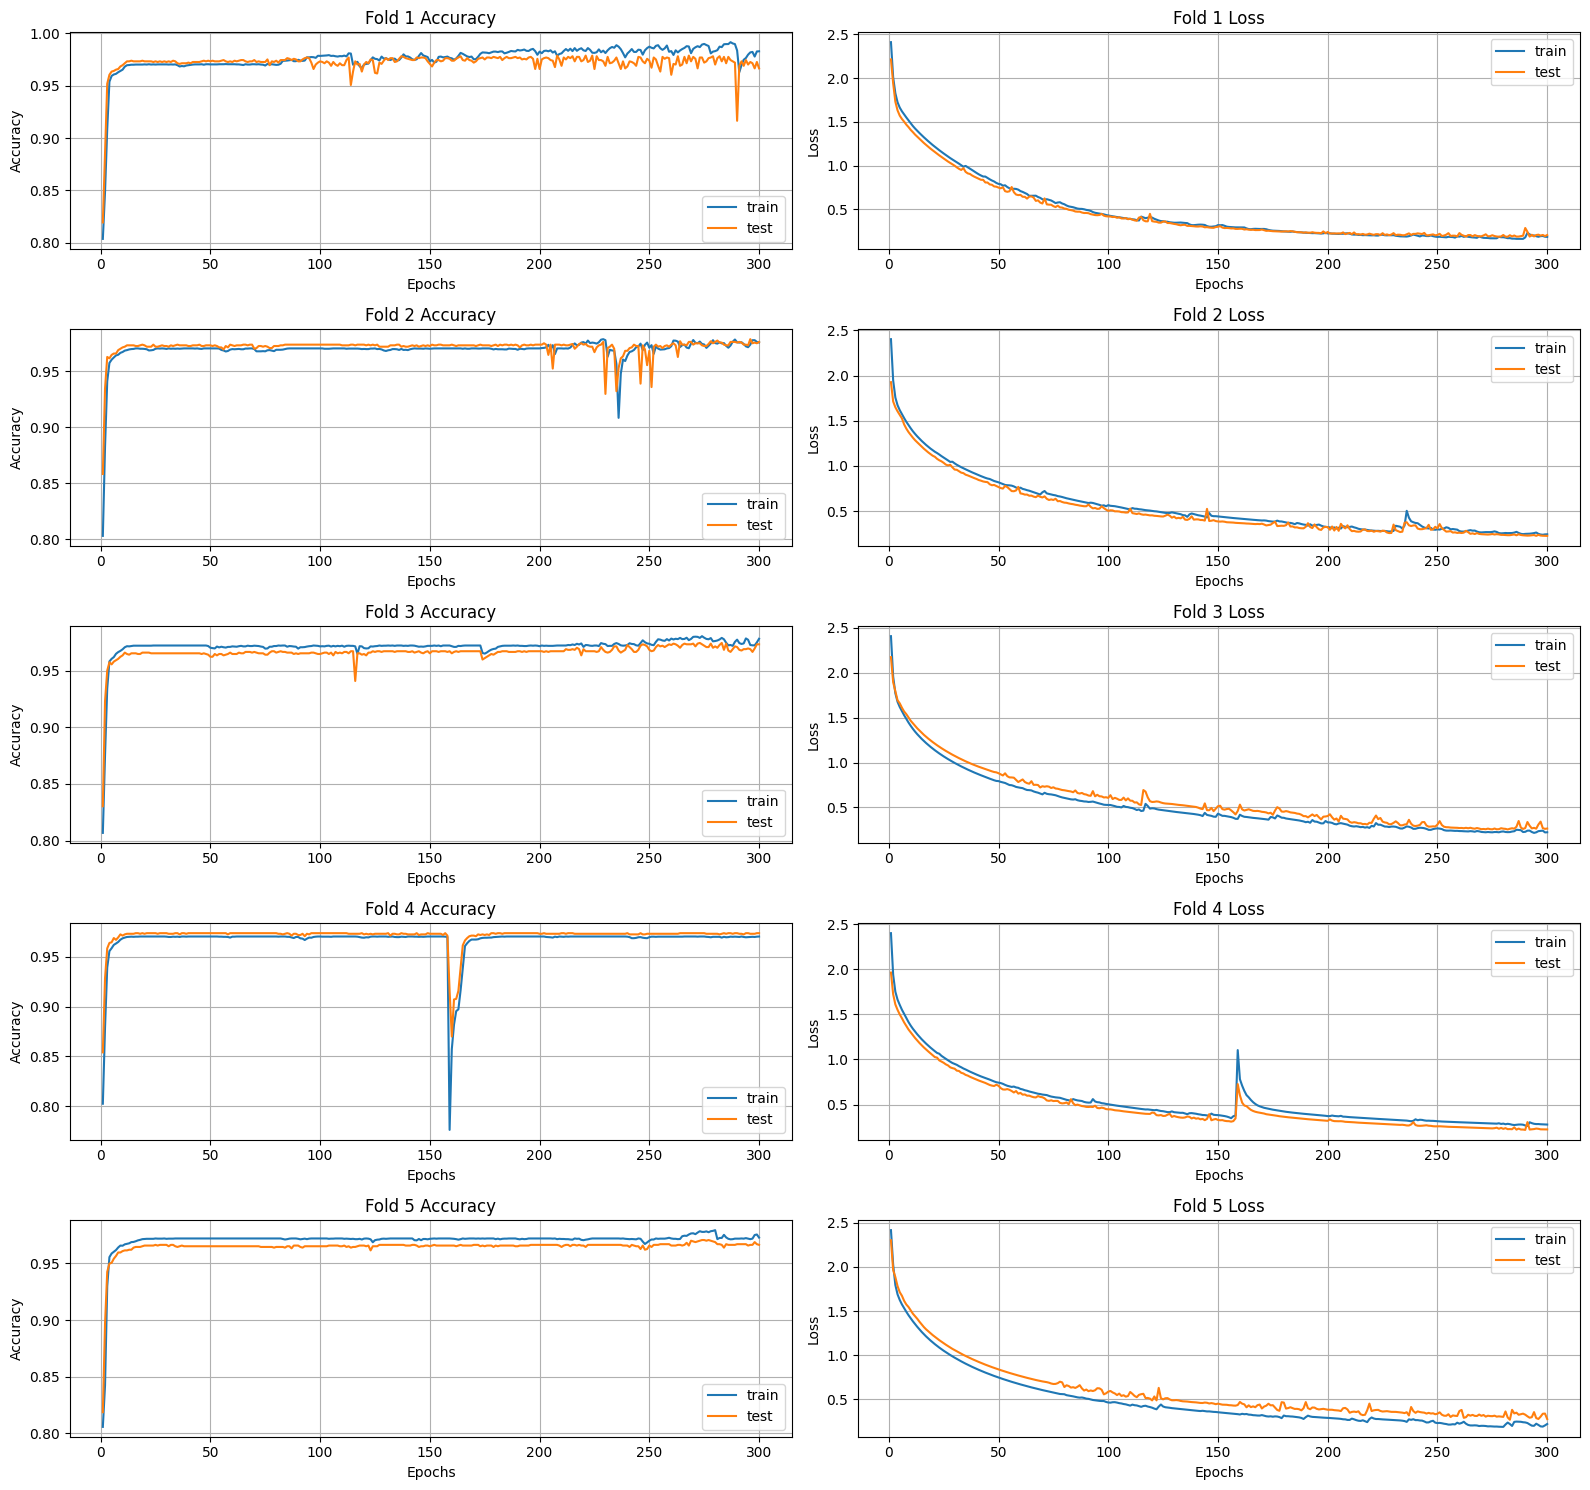

In [17]:
# Select best fold
best_fold = max(folds_res, key=lambda fold: fold['test_acc'][-1])

fig, axs = plt.subplots(len(folds_res), 2, figsize=(16, 15))

for idx, fold in enumerate(folds_res):
    axs[idx, 0].plot(np.arange(1, epochs+1), fold['train_acc'], label='train')
    axs[idx, 0].plot(np.arange(1, epochs+1), fold['test_acc'], label='test')
    axs[idx, 0].set_ylabel('Accuracy')
    axs[idx, 0].set_xlabel('Epochs')
    axs[idx, 0].set_title(f'Fold {idx+1} Accuracy')
    axs[idx, 0].legend()
    axs[idx, 0].grid()

    axs[idx, 1].plot(np.arange(1, epochs+1), fold['train_losses'], label='train')
    axs[idx, 1].plot(np.arange(1, epochs+1), fold['test_losses'], label='test')
    axs[idx, 1].set_ylabel('Loss')
    axs[idx, 1].set_xlabel('Epochs')
    axs[idx, 1].set_title(f'Fold {idx+1} Loss')
    axs[idx, 1].legend()
    axs[idx, 1].grid()

plt.tight_layout()
plt.show()

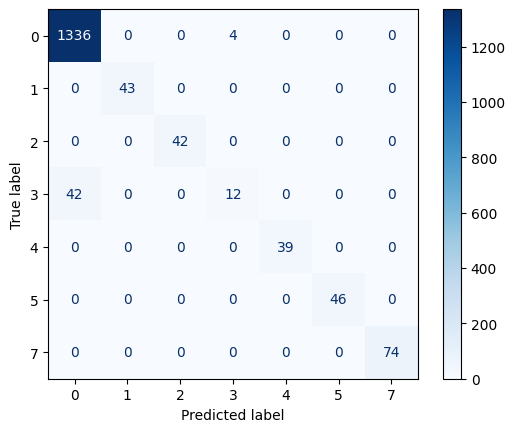

In [19]:
model.load_weights(f'.\\models\\{best_fold["fold"]}-fold-model.weights.h5')

y_pred, y_true = np.array([]), np.array([])
for x_batch, y_batch in test_ds:
    probs = tf.nn.softmax(model(x_batch), axis=1).numpy()
    y_pred = np.hstack((y_pred, np.argmax(probs, axis=1)))
    y_true = np.hstack((y_true, y_batch.numpy().ravel()))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.show()

In [20]:
for label in np.unique(y):
    indexes = np.where(y == label)[0]

    ds = tf.data.Dataset.from_tensor_slices((X[indexes], y[indexes])).batch(indexes.shape[0])

    for x_batch, y_batch in ds:
        probs = tf.nn.softmax(model(x_batch), axis=1).numpy()
        y_pred = np.argmax(probs, axis=1)
        y_true = y_batch.numpy().ravel()

        acc = np.sum(y_pred == y_true) / y_true.shape[0]

        print(f'Class: {label}, Accuracy: {acc * 100:.2f} %')

Class: 0, Accuracy: 99.79 %
Class: 1, Accuracy: 100.00 %
Class: 2, Accuracy: 100.00 %
Class: 3, Accuracy: 21.52 %
Class: 4, Accuracy: 100.00 %
Class: 5, Accuracy: 100.00 %
Class: 7, Accuracy: 100.00 %
